In [ ]:
import kagglehub

path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-12k-images-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-12k-images-dataset


In [ ]:
import os

print(os.listdir(path))

['Face Mask Dataset']


In [ ]:
for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-" * 50)

/kaggle/input/face-mask-12k-images-dataset
Folders: ['Face Mask Dataset']
Files: 0
--------------------------------------------------
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset
Folders: ['Validation', 'Test', 'Train']
Files: 0
--------------------------------------------------
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation
Folders: ['WithoutMask', 'WithMask']
Files: 0
--------------------------------------------------
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation/WithoutMask
Folders: []
Files: 400
--------------------------------------------------
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation/WithMask
Folders: []
Files: 400
--------------------------------------------------
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test
Folders: ['WithoutMask', 'WithMask']
Files: 0
--------------------------------------------------
/kaggle/input/face-mask-12k-images-dataset/Face Mask Datase

In [ ]:
dataset_path = os.path.join(path, "Face Mask Dataset")

train_dir = os.path.join(dataset_path, "Train")
val_dir = os.path.join(dataset_path, "Validation")
test_dir = os.path.join(dataset_path, "Test")

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train
Validation: /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation
Test: /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test


In [ ]:
print("Train classes:", os.listdir(train_dir))
print("Validation classes:", os.listdir(val_dir))
print("Test classes:", os.listdir(test_dir))

Train classes: ['WithoutMask', 'WithMask']
Validation classes: ['WithoutMask', 'WithMask']
Test classes: ['WithoutMask', 'WithMask']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

DataSet Loading

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

print("Classes:", train_ds.class_names)

Found 10000 files belonging to 2 classes.
Classes: ['WithMask', 'WithoutMask']


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 800 files belonging to 2 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 992 files belonging to 2 classes.


Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

VGG16 Pretrained model

In [ ]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
print("Total layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

Total layers: 19
Trainable: False


VGG16 preprocessing

In [ ]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
class_names = os.listdir(train_dir)

print("Classes:", class_names)

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name}: {count} images")

Classes: ['WithoutMask', 'WithMask']
WithoutMask: 5000 images
WithMask: 5000 images


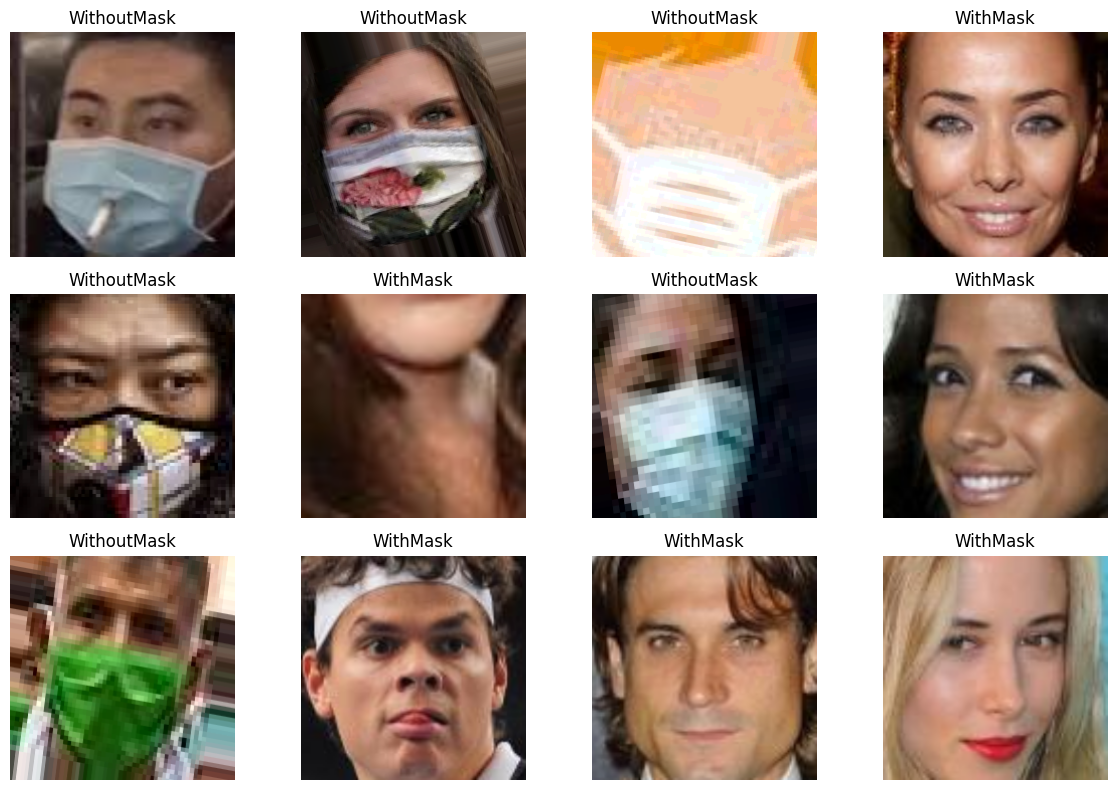

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

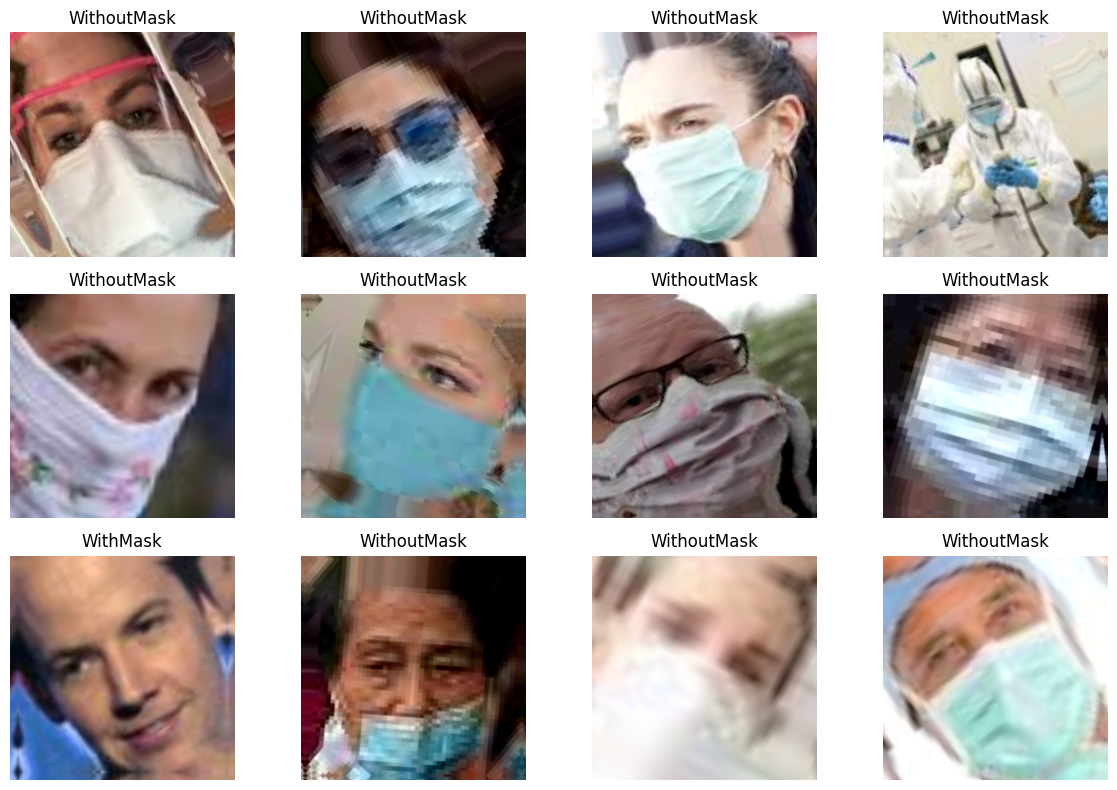

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    augmented_images = data_augmentation(images)

    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(
            augmented_images[i].numpy().astype("uint8")
        )

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model.non_trainable_weights
)

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Trainable parameters: 131585
Non-trainable parameters: 14714688


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_vgg16_mask_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

Training


In [ ]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8051 - loss: 0.7203 - precision: 0.8098 - recall: 0.7989
Epoch 1: val_accuracy improved from None to 0.99875, saving model to best_vgg16_mask_model.keras

Epoch 1: finished saving model to best_vgg16_mask_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - accuracy: 0.9142 - loss: 0.2858 - precision: 0.9179 - recall: 0.9098 - val_accuracy: 0.9987 - val_loss: 0.0073 - val_precision: 0.9975 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9871 - loss: 0.0406 - precision: 0.9863 - recall: 0.9877
Epoch 2: val_accuracy did not improve from 0.99875
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - accuracy: 0.9860 - loss: 0.0471 - precision: 0.9862 - recall: 0.9858 - val_accuracy: 0.9987 - val_loss: 0.0031 - val_precision: 0.9975 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9905 - loss

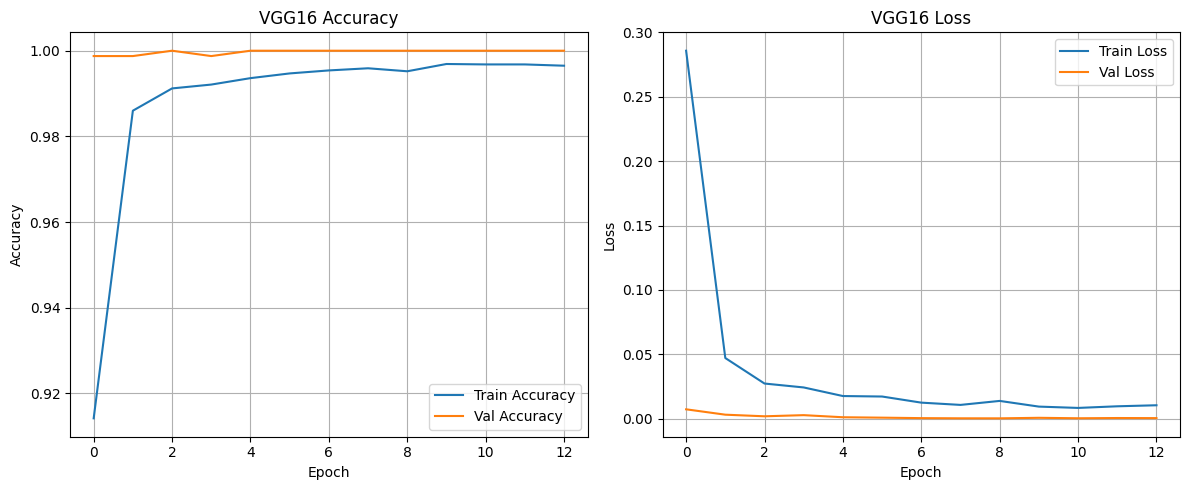

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Accuracy")

plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
best_model = tf.keras.models.load_model(
    "best_vgg16_mask_model.keras"
)
print("Best model loaded successfully.")

Best model loaded successfully.


Testing

In [ ]:
test_results = best_model.evaluate(
    test_ds,
    verbose=1
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.9960 - loss: 0.0152 - precision: 0.9941 - recall: 0.9980


In [ ]:
print("\nTest Results:")

for name, value in zip(best_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")


Test Results:
loss: 0.0152
compile_metrics: 0.9960


Confusion Metrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Actual labels
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

# Predictions
y_prob = best_model.predict(test_ds)
y_pred = (y_prob > 0.5).astype(int).ravel()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names # Use the global class_names variable
    )
)


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step
Confusion Matrix:
[[480   3]
 [  1 508]]

Classification Report:
              precision    recall  f1-score   support

 WithoutMask       1.00      0.99      1.00       483
    WithMask       0.99      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992



Model Save

In [ ]:
MODEL_PATH = "/content/face_mask_vgg16.keras"

best_model.save(MODEL_PATH)

print("Model saved at:", MODEL_PATH)

Model saved at: /content/face_mask_vgg16.keras


In [ ]:

print("Exists:", os.path.exists(MODEL_PATH))
print("Size:", os.path.getsize(MODEL_PATH) / (1024 * 1024), "MB")

Exists: True
Size: 57.74363708496094 MB


In [ ]:
loaded_model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


Single Image Prediction

In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

class_names = ["WithMask", "WithoutMask"]

def predict_mask(image_path):

    # Load image
    image = load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert to array
    image_array = img_to_array(image)

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # VGG16 preprocessing
    image_array = preprocess_input(image_array)

    # Prediction
    probability = loaded_model.predict(
        image_array,
        verbose=0
    )[0][0]

    # Convert probability to class
    predicted_class = (
        "WithoutMask" if probability >= 0.5
        else "WithMask"
    )

    confidence = (
        probability if probability >= 0.5
        else 1 - probability
    )

    return predicted_class, confidence

In [ ]:
with_mask_dir = os.path.join(
    test_dir,
    "WithMask"
)

with_mask_image = os.path.join(
    with_mask_dir,
    os.listdir(with_mask_dir)[0]
)

print("Testing:", with_mask_image)

prediction, confidence = predict_mask(
    with_mask_image
)

print("Prediction:", prediction)
print(f"Confidence: {confidence:.2%}")

Testing: /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithMask/Augmented_735_9235977.png
Prediction: WithMask
Confidence: 100.00%


In [ ]:
without_mask_dir = os.path.join(
    test_dir,
    "WithoutMask"
)

without_mask_image = os.path.join(
    without_mask_dir,
    os.listdir(without_mask_dir)[0]
)

print("Testing:", without_mask_image)

prediction, confidence = predict_mask(
    without_mask_image
)

print("Prediction:", prediction)
print(f"Confidence: {confidence:.2%}")

Testing: /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithoutMask/4353.png
Prediction: WithoutMask
Confidence: 99.49%


In [ ]:
print(class_names)

['WithMask', 'WithoutMask']


In [ ]:
import matplotlib.pyplot as plt

def show_prediction(image_path):

    prediction, confidence = predict_mask(image_path)

    image = load_img(image_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(
        f"{prediction} | Confidence: {confidence:.2%}"
    )
    plt.axis("off")
    plt.show()

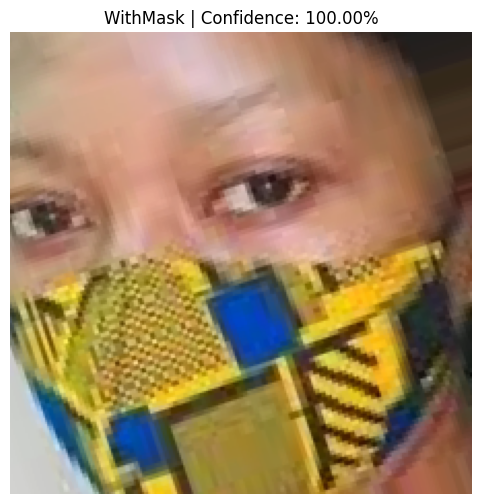

In [ ]:
show_prediction(with_mask_image)

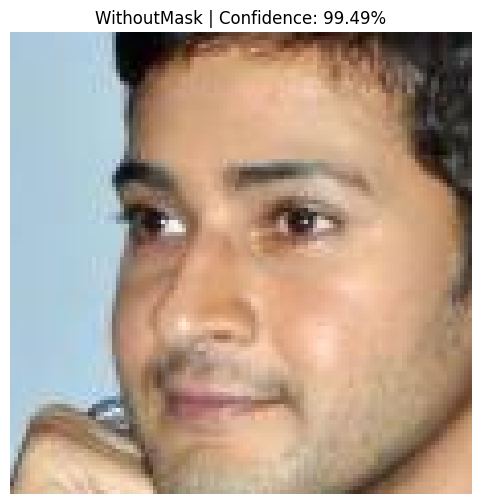

In [ ]:
show_prediction(without_mask_image)

In [ ]:
from google.colab import files

files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>